---
title: C.3re tanglegrams 
author: Elgin Akin
date: 2025-05-19
---

Useful resources: 
- [baltic](https://github.com/evogytis/baltic/blob/master/docs/notebooks/austechia.ipynb)
- [A nice blog by Gytis on reassortment](https://evogytis.github.io/posts/2020/10/reassortment/)

# Plot HA colored by subclade

In [1]:
import baltic as bt
import matplotlib as mpl
from matplotlib import pyplot as plt

# set global fonts 

typeface='Helvetica Neue'
mpl.rcParams['font.weight']=300
mpl.rcParams['axes.labelweight']=300
mpl.rcParams['font.family']=typeface
mpl.rcParams['font.size']=22

# Load tree
genome = "../auspice/vic/genome.json"

tree= bt.loadJSON(genome)

# Define your subclade color palette
subclade_colors = {
    "C.5.1": "#e7298a",
    "C.5.5": "#66c2a5",
    "C.5.6": "#2E6F40",
    "C.5.7": "#666666",
    "C.5": "#e6ab02",
    "C.3": "#a6761d"
}

# Define a color function for the tips
def c_func(node):
    subclade = node.traits.get('subclade')  # Get the 'subclade' attribute
    return subclade_colors.get(subclade, 'lightgrey')  # Default to grey if subclade is not in the palette

L=len(list(filter(lambda k: k.branchType=='leaf',tree[0].Objects)))
b_func=lambda k: 2+10.0*len(k.leaves)/float(L) if k.branchType=='node' else 2 ## branch width is determined by how many descendants a node has, otherwise 2 (tips)

fig, ax = plt.subplots(figsize=(5, 10), facecolor='w')

x_attr = lambda k: k.absoluteTime  # Use absolute time for x-axis

# Plot the tree and tips
tree[0].plotTree(ax,
                connection_type = "baltic",
                x_attr=x_attr, 
                colour='k',  # Plot tree branches in black
                width = 1,
                #width = b_func,
                #colour = c_func)
                )
tree[0].plotPoints(ax, 
                x_attr=x_attr, 
                size=10, 
                outline = True,
                outline_colour = "black", 
                colour=c_func, 
                zorder=100)  # Color tips based on subclade

# Aesthetics
ax.xaxis.tick_bottom()
ax.set_ylim(-5, tree[0].ySpan + 5)  # Adjust y-axis limits
ax.set_yticks([])  # Remove y-axis ticks
ax.set_yticklabels([])  # Remove y-axis labels
[ax.spines[loc].set_visible(False) for loc in ax.spines if loc not in ['bottom']]  # Hide spines except bottom

#plt.savefig('../figures/01_B_genome-tree-baltic',dpi=300, bbox_inches='tight')
plt.show()


ModuleNotFoundError: No module named 'baltic'

## Tanglegram


> Copy over all auspice json's to a new sub-directory for easly looping and plotting


Sources: 
- https://github.com/dven42/phylogenetic-incongruence/blob/master/BALTIC.ipynb
- https://journals.plos.org/plospathogens/article?id=10.1371/journal.ppat.1006466
- https://github.com/blab/siv-cst/blob/master/figures/main-text/F1-recombination.ipynb

## Impport Trees

In [4]:
import baltic as bt
from glob import glob
from IPython.display import HTML
import re
import copy

import matplotlib as mpl
from matplotlib import pyplot as plt
import matplotlib.patheffects as path_effects
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Polygon

import numpy as np
from scipy.special import binom
import itertools
import requests

from io import StringIO as sio
from io import BytesIO as csio

from Bio import Phylo


treefiles = glob('../auspice/plotting/*.json')


segments=['PB1','PB2','PA','HA','NP','NA','MP','NS']

trees={} ## dict
for segment in segments:
    print(segment, )
    tree_location = f"../auspice/vic/{segment}.json"

    ll = bt.loadJSON(tree_location)
    trees[segment]=ll[0] ## add ONLY the tree object to dict

print('\nDone!')

PB1

Tree height: 6.044534
Tree length: 1340.864266
annotations present

Numbers of objects in tree: 4179 (1679 nodes and 2500 leaves)

PB2

Tree height: 9.509687
Tree length: 1414.206972
annotations present

Numbers of objects in tree: 4235 (1735 nodes and 2500 leaves)

PA

Tree height: 7.099743
Tree length: 1109.577495
annotations present

Numbers of objects in tree: 4324 (1824 nodes and 2500 leaves)

HA

Tree height: 7.812662
Tree length: 1225.729473
annotations present

Numbers of objects in tree: 4328 (1828 nodes and 2500 leaves)

NP

Tree height: 5.907860
Tree length: 1351.510923
annotations present

Numbers of objects in tree: 4333 (1833 nodes and 2500 leaves)

NA

Tree height: 8.968980
Tree length: 1437.812630
annotations present

Numbers of objects in tree: 4214 (1714 nodes and 2500 leaves)

MP

Tree height: 7.895951
Tree length: 1659.952300
annotations present

Numbers of objects in tree: 4360 (1860 nodes and 2500 leaves)

NS

Tree height: 6.519779
Tree length: 1713.233046
an

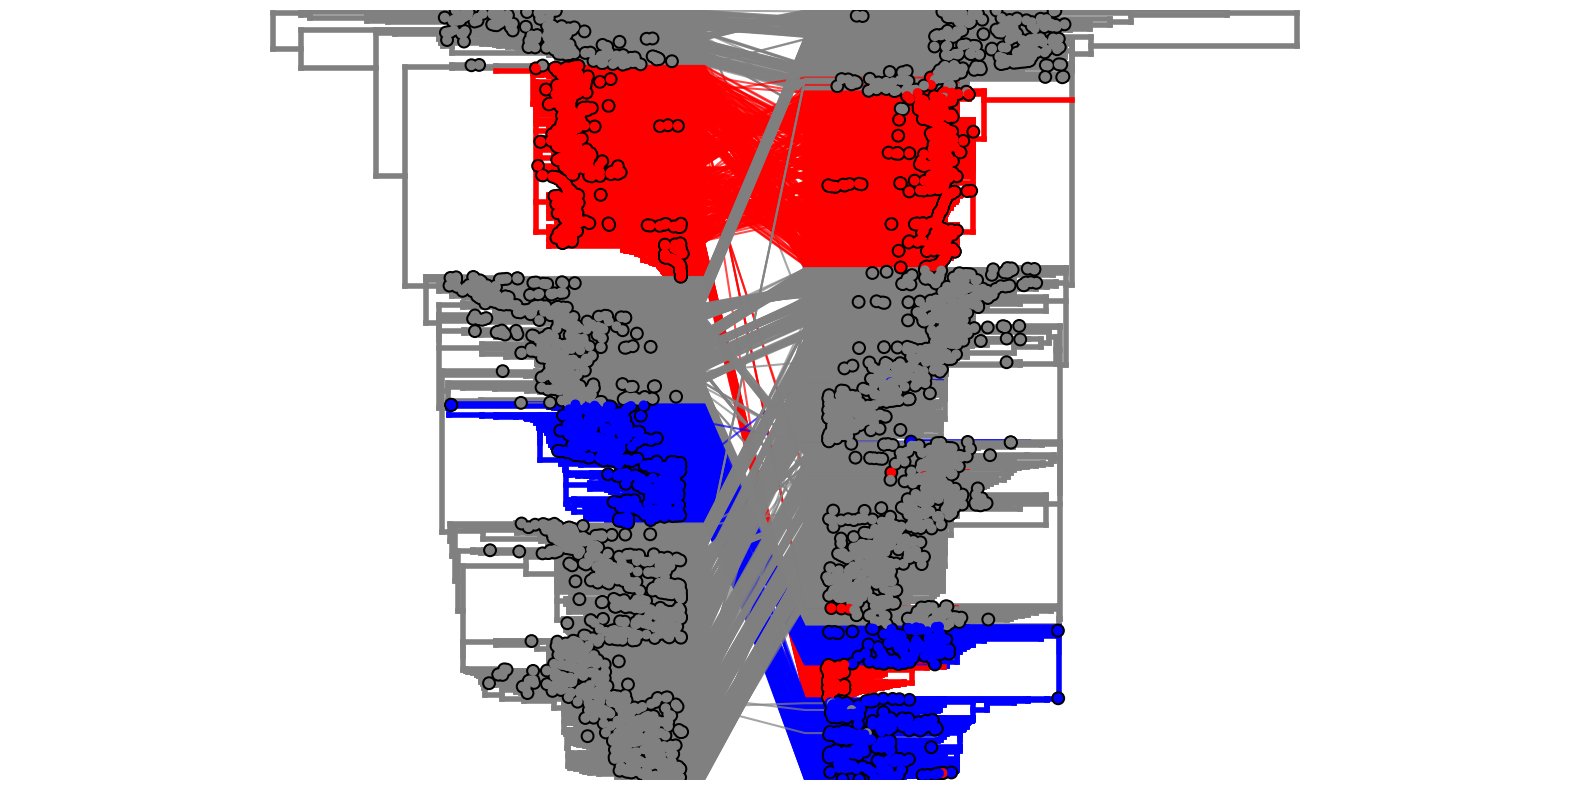

In [7]:
# Plot a tanglegram between PB1 and PB2, coloring by subclade

import matplotlib as mpl
from matplotlib import pyplot as plt
from matplotlib.gridspec import GridSpec

# Set up figure and axes
fig = plt.figure(figsize=(20, 10), facecolor='w')
gs = GridSpec(1, 1, hspace=0.0, wspace=0.0)
ax = plt.subplot(gs[0])

traitName = 'subclade'
tree1 = trees["HA"]
tree2 = trees["NA"]

# Color function for subclade
subclade_colors = {
    'C.3': 'red',
    'C.5.1': 'blue'
}
def c_func(k):
    return subclade_colors.get(k.traits.get(traitName), 'grey')

cmap = mpl.cm.cividis
x_attr1 = lambda k: k.height

# Plot first tree
tree1.plotTree(ax, x_attr=x_attr1, width=4, colour=c_func)
tree1.plotPoints(ax, x_attr=x_attr1, size=50, colour=c_func, zorder=100)

# Offset for second tree
skip = tree1.treeHeight * 0.35
x_attr2 = lambda k: tree1.treeHeight + skip + tree2.treeHeight - k.height

# Plot second tree
tree2.plotTree(ax, x_attr=x_attr2, width=4, colour=c_func)
tree2.plotPoints(ax, x_attr=x_attr2, size=50, colour=c_func, zorder=100)

# Draw tangle lines between matching tips
for k in filter(lambda x: x.branchType == 'leaf', tree1.Objects):
    x = k.height
    y = k.y
    # Set warn=False to avoid exceptions if no match is found
    matching = tree2.getBranches(lambda x2: x2.branchType == 'leaf' and x2.name == k.name, warn=False)
    if not matching:
        continue
    # Handle both list and single object return types
    if isinstance(matching, list):
        matching_tip = matching[0]
    else:
        matching_tip = matching
    match_y = matching_tip.y
    xs = [x, tree1.treeHeight + 0.15 * skip, tree1.treeHeight + skip - 0.15 * skip, x_attr2(matching_tip)]
    ys = [y, y, match_y, match_y]
    color = subclade_colors.get(k.traits.get(traitName), 'grey')
    ax.plot(xs, ys, color=color, alpha=0.7)

# Clean up plot aesthetics
for loc in ['top', 'right', 'left', 'bottom']:
    ax.spines[loc].set_visible(False)
ax.tick_params(axis='x', size=0)
ax.tick_params(axis='y', size=0)
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.set_ylim(-1, tree1.ySpan + 1)
ax.set_xlim(-5, tree1.treeHeight + skip + tree2.treeHeight + 5)

plt.show()

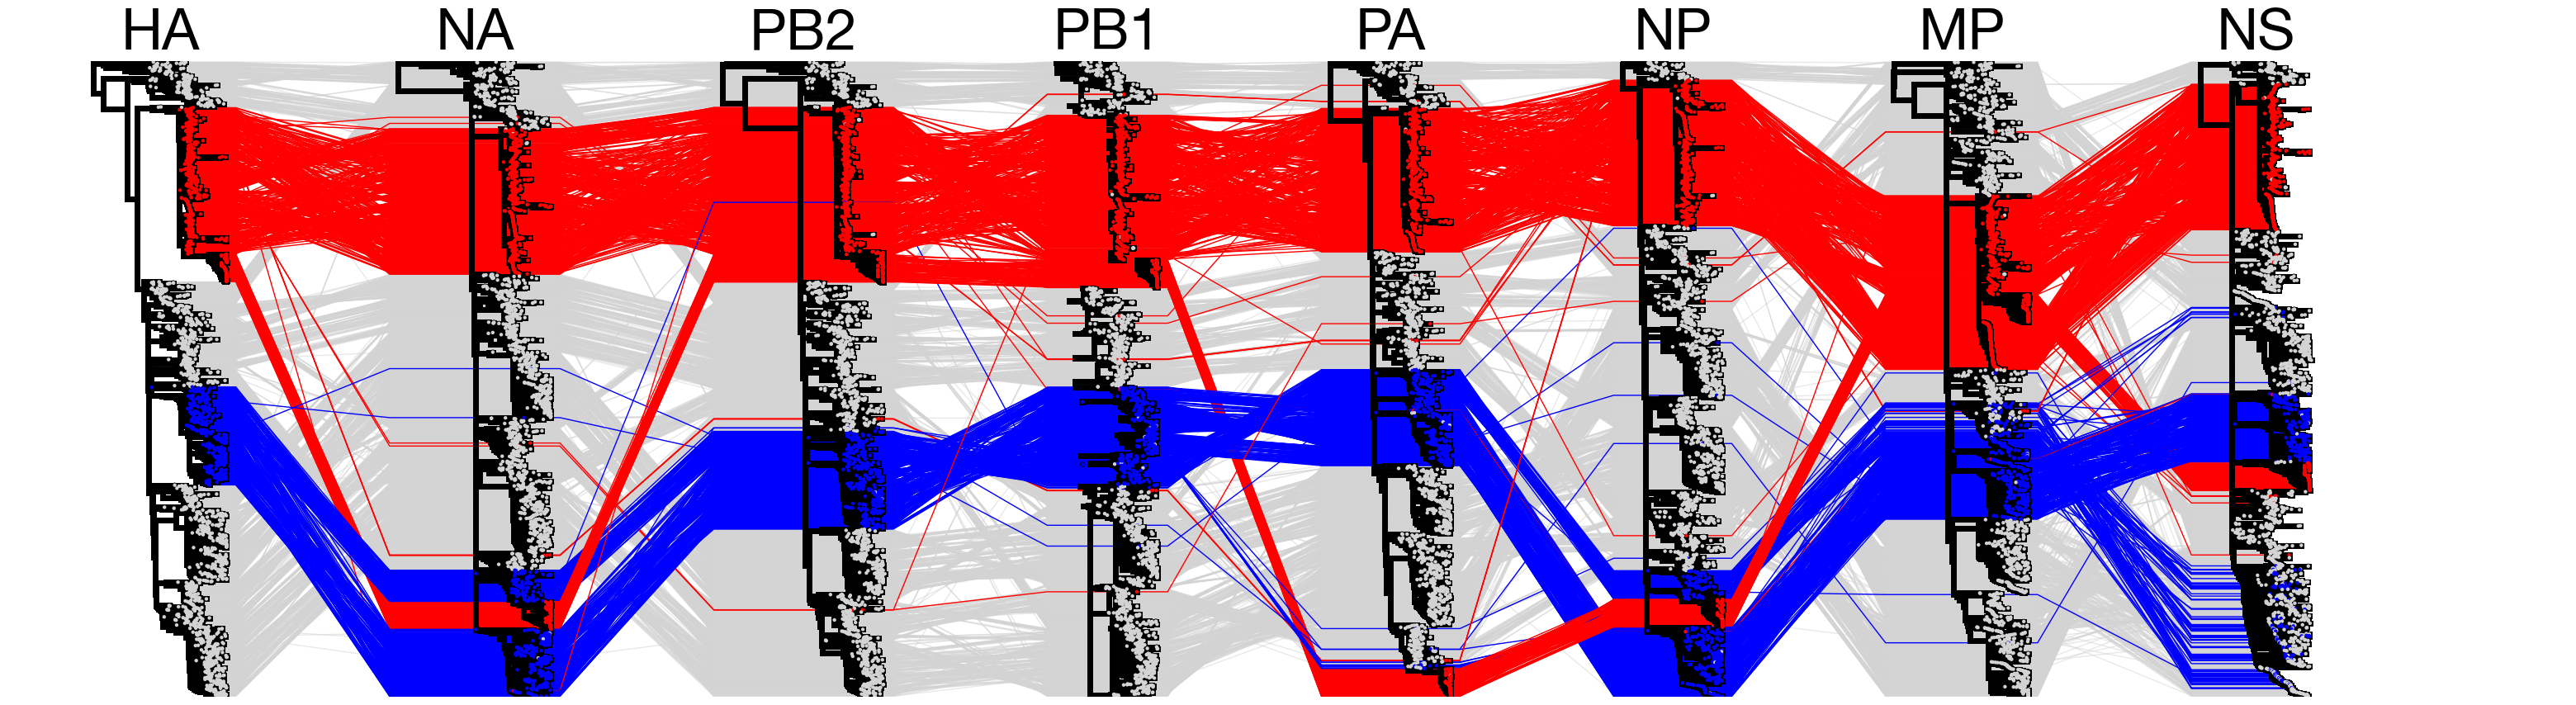

In [ ]:
# some aesthetic hanges...

import baltic as bt
import matplotlib as mpl
from matplotlib import pyplot as plt

fig, ax = plt.subplots(figsize=(40, 10), facecolor='w')

traitName = 'subclade'
cumulative_displace = 0
#tree_names = ['PB2', 'PB1', 'PA', 'HA', 'NP', 'NA', 'MP', 'NS']
tree_names = ['HA', 'NA', 'PB2', 'PB1', 'PA', 'NP', 'MP', 'NS']
displaceAmount = 10
subclade_colors = {'C.3': 'red', 'C.5.1': 'blue'}
non_re_subclades = 'lightgrey'

for t, tr in enumerate(tree_names):
    cur_tree = trees[tr]
    x_attr = lambda k: k.height + cumulative_displace

    def colour_func(node):
        return subclade_colors.get(node.traits.get(traitName), non_re_subclades)
    
    cur_tree.plotTree(ax, x_attr=x_attr, width=5, colour="black")
    cur_tree.plotPoints(ax, x_attr=x_attr, size=10, colour=colour_func, zorder=100)

    # Add label above tree
    tree_center = cumulative_displace + cur_tree.treeHeight / 2
    ax.text(tree_center, cur_tree.ySpan + 4, tr, ha='center', va='bottom', fontsize=50, fontweight='bold')

    for k in cur_tree.Objects:
        if k.branchType == 'leaf' and t != len(tree_names) - 1:
            next_tree = tree_names[t + 1]
            if k.name in tip_positions[next_tree]:
                next_x, next_y = tip_positions[next_tree][k.name]
                next_x += cumulative_displace + cur_tree.treeHeight + displaceAmount
                nextIncrement = cumulative_displace + cur_tree.treeHeight

                color = subclade_colors.get(k.traits.get(traitName), non_re_subclades)
                is_grey = (color == non_re_subclades)

                ax.plot(
                    [x_attr(k), nextIncrement + 0.05 * displaceAmount,
                     nextIncrement + 0.95 * displaceAmount, next_x],
                    [k.y, k.y, next_y, next_y],
                    lw=1,
                    ls='-',
                    color=color,
                    alpha=0.5 if is_grey else 1.0,
                    zorder=0 if is_grey else 1
                )

    cumulative_displace += cur_tree.treeHeight + displaceAmount

[ax.spines[loc].set_visible(False) for loc in ['top', 'right', 'left', 'bottom']]
ax.tick_params(axis='x', size=0)
ax.tick_params(axis='y', size=0)
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.set_ylim(-1, cur_tree.ySpan + 3)
ax.set_xlim(-5, cumulative_displace + 5)

plt.show()


In [ ]:
# lets add a legend and maybe some lables 




# Calculating tMRCA between C.3 and C.3re by segment

## HA 

In [9]:
myTree, mymeta = bt.loadJSON("../auspice/vic/ha.json")
tmrca_matrix = myTree.allTMRCAs()


Tree height: 7.812662
Tree length: 1225.729473
annotations present

Numbers of objects in tree: 4328 (1828 nodes and 2500 leaves)



In [10]:
tip1, tip2 = "JH251289", "JH251043" #JH251289 = C.3 , JH251043=C.5.1 
print(f"TMRCA between {tip1} and {tip2}: {tmrca_matrix[tip1][tip2]}")


TMRCA between JH251289 and JH251043: 2020.0531689328477


# Identify MRCA of C.3, C.3re and C.5.1 

In [8]:
#https://github.com/evogytis/baltic/wiki/Method-%60baltic.tree.commonAncestor%60

# Representatives for: 
# C.3 
# C.3re 
# C.5.1


# Assuming we have a tree and some leaf nodes
leaf1 = myTree.getExternal()[0]
leaf2 = myTree.getExternal()[5]
leaf3 = myTree.getExternal()[10]

# Find the common ancestor of these three leaves
mrca = myTree.commonAncestor([leaf1, leaf2, leaf3])

mrca
print(f"Common ancestor index: {mrca.index}")
print(f"Height of common ancestor: {mrca.height}")

# We can also use this to check if a set of leaves form a monophyletic group
all_leaves = myTree.getExternal()
group_of_interest = all_leaves[:5]  # First 5 leaves
mrca_of_group = myTree.commonAncestor(group_of_interest)

is_monophyletic = set(mrca_of_group.leaves) == set(leaf.name for leaf in group_of_interest)
print(f"Is the group monophyletic? {is_monophyletic}")



NameError: name 'myTree' is not defined